# Insurance Claim Cost Prediction and Fraud Detection
### End-to-End Data Science Analysis

**Author:** Marzieh Abbasi  
**Course:** DSC 530 – Data Exploration and Analysis  
**Institution:** Bellevue University

# Executive Summary

Insurance companies rely heavily on predictive analytics to estimate potential claim costs and detect fraudulent claims. Inaccurate predictions can result in financial loss, improper pricing strategies, and increased operational risk.

This project performs a complete end-to-end data science workflow on an insurance claims dataset. The analysis combines statistical analysis, exploratory data analysis (EDA), supervised machine learning, and unsupervised learning techniques.

The main goals of this project are:

• Identify key drivers of insurance claim costs  
• Develop predictive models for estimating claim amounts  
• Detect potentially fraudulent claims using classification algorithms  
• Discover hidden behavioral segments among policyholders  

The methodology implemented in this project reflects a real-world data science pipeline used in insurance analytics.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set(style="whitegrid")

print("Libraries successfully loaded.")

Libraries successfully loaded.


# Load Dataset
# Dataset Description

The dataset contains insurance claim records including customer demographics, policy information, and claim outcomes.

The dataset consists of approximately **1000 observations** with multiple features describing policyholder characteristics and incident details.

## Key Variables

| Variable | Description |
|--------|-------------|
| total_claim_amount | Total payout amount for the claim |
| age | Policyholder age |
| months_as_customer | Customer tenure |
| incident_severity | Severity level of the claim |
| fraud_reported | Binary indicator of whether fraud was reported |

Two main modeling tasks are explored in this analysis:

1. Regression – Predicting claim cost  
2. Classification – Detecting fraudulent claims


In [3]:
df = pd.read_csv("../data/raw/insurance_claims.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (1000, 40)


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   str    
 4   policy_state                 1000 non-null   str    
 5   policy_csl                   1000 non-null   str    
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   str    
 11  insured_education_level      1000 non-null   str    
 12  insured_occupation           1000 non-null   str    
 13  insured_hobbies              1

In [5]:
df.describe()

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,_c39
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,0.0
mean,203.954000,38.948000,546238.648000,1136.000000,1256.406150,1.101000e+06,501214.488000,25126.100000,-26793.700000,11.644000,1.83900,0.992000,1.487000,52761.94000,7433.420000,7399.570000,37928.950000,2005.103000,NaN
std,115.113174,9.140287,257063.005276,611.864673,244.167395,2.297407e+06,71701.610941,27872.187708,28104.096686,6.951373,1.01888,0.820127,1.111335,26401.53319,4880.951853,4824.726179,18886.252893,6.015861,NaN
min,0.000000,19.000000,100804.000000,500.000000,433.330000,-1.000000e+06,430104.000000,0.000000,-111100.000000,0.000000,1.00000,0.000000,0.000000,100.00000,0.000000,0.000000,70.000000,1995.000000,NaN
25%,115.750000,32.000000,335980.250000,500.000000,1089.607500,0.000000e+00,448404.500000,0.000000,-51500.000000,6.000000,1.00000,0.000000,1.000000,41812.50000,4295.000000,4445.000000,30292.500000,2000.000000,NaN
50%,199.500000,38.000000,533135.000000,1000.000000,1257.200000,0.000000e+00,466445.500000,0.000000,-23250.000000,12.000000,1.00000,1.000000,1.000000,58055.00000,6775.000000,6750.000000,42100.000000,2005.000000,NaN
75%,276.250000,44.000000,759099.750000,2000.000000,1415.695000,0.000000e+00,603251.000000,51025.000000,0.000000,17.000000,3.00000,2.000000,2.000000,70592.50000,11305.000000,10885.000000,50822.500000,2010.000000,NaN
max,479.000000,64.000000,999435.000000,2000.000000,2047.590000,1.000000e+07,620962.000000,100500.000000,0.000000,23.000000,4.00000,2.000000,3.000000,114920.00000,21450.000000,23670.000000,79560.000000,2015.000000,NaN


In [6]:
df.isnull().sum()

months_as_customer                0
age                               0
policy_number                     0
policy_bind_date                  0
policy_state                      0
policy_csl                        0
policy_deductable                 0
policy_annual_premium             0
umbrella_limit                    0
insured_zip                       0
insured_sex                       0
insured_education_level           0
insured_occupation                0
insured_hobbies                   0
insured_relationship              0
capital-gains                     0
capital-loss                      0
incident_date                     0
incident_type                     0
collision_type                    0
incident_severity                 0
authorities_contacted            91
incident_state                    0
incident_city                     0
incident_location                 0
incident_hour_of_the_day          0
number_of_vehicles_involved       0
property_damage             

# Data Cleaning


In [7]:
df = df.replace("?", np.nan)

df = df.drop(columns=["_c39"], errors="ignore")

numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,0,NO,5070,780,780,3510,Mercedes,E400,2007,Y
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,1,NO,6500,1300,650,4550,Accura,RSX,2009,N


# Feature Engineering


In [9]:
df["claim_per_month"] = df["total_claim_amount"] / (df["months_as_customer"] + 1)

df["age_group"] = pd.cut(
    df["age"],
    bins=[18,30,40,50,60,100],
    labels=["18-30","30-40","40-50","50-60","60+"]
)

In [10]:
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

C:\Users\asus\AppData\Local\Temp\ipykernel_6324\2852344203.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


# Professional EDA (10 Visualizations)


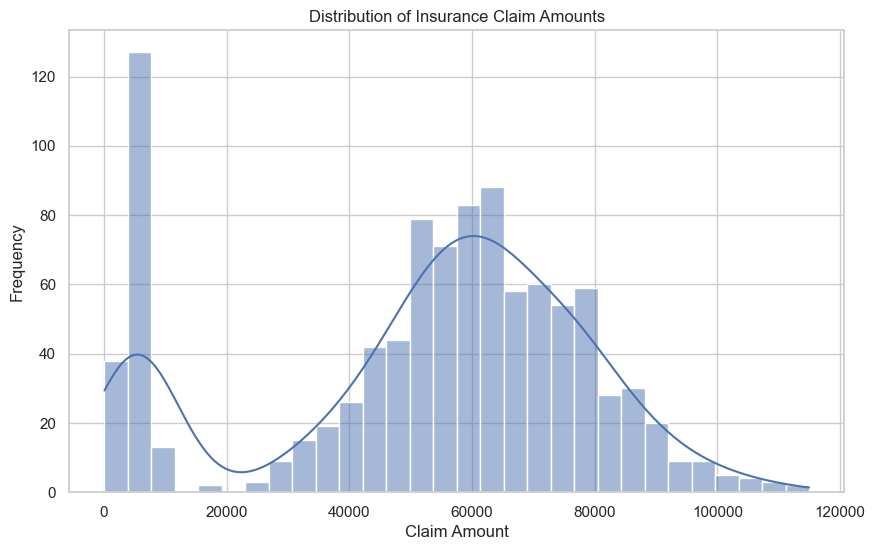

In [11]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["total_claim_amount"],
    bins=30,
    kde=True
)

plt.title("Distribution of Insurance Claim Amounts")

plt.savefig("../reports/figures/claim_distribution.png")

plt.xlabel("Claim Amount")

plt.ylabel("Frequency")

plt.show()

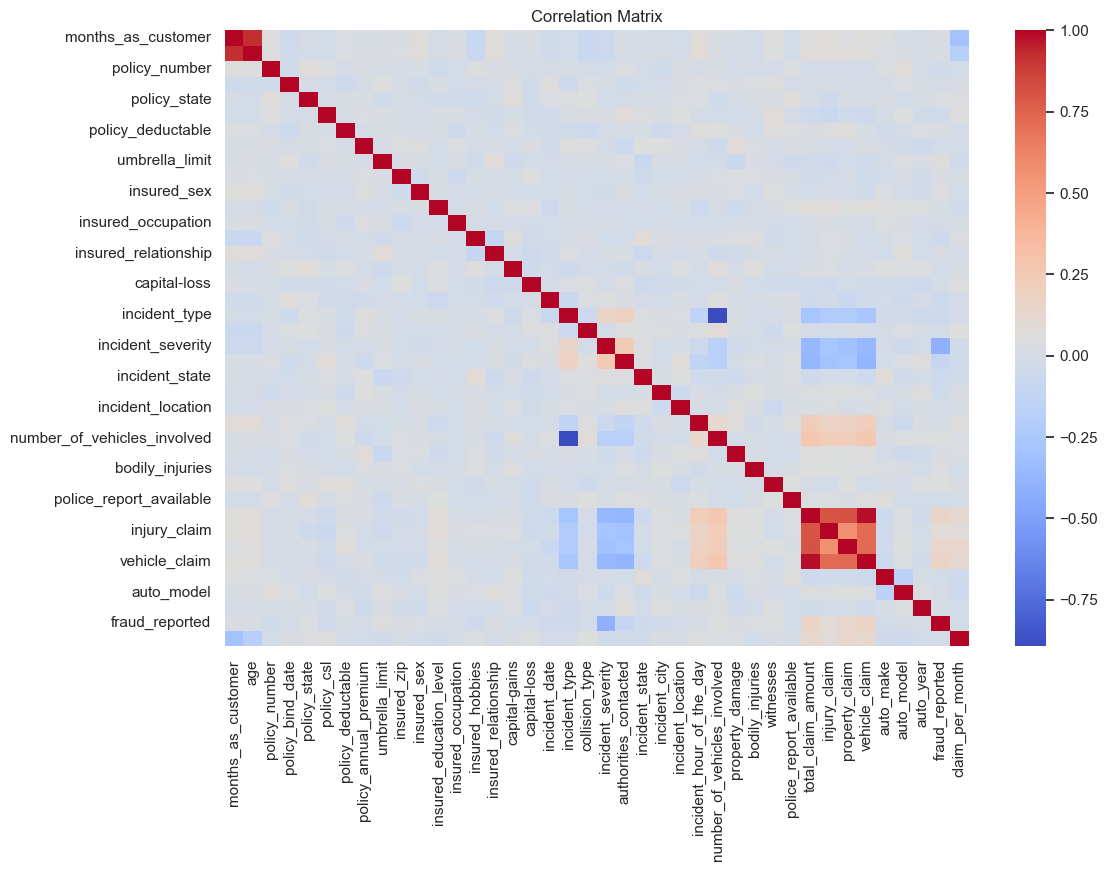

In [12]:
corr = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.savefig("../reports/figures/correlation_matrix.png")

plt.show()

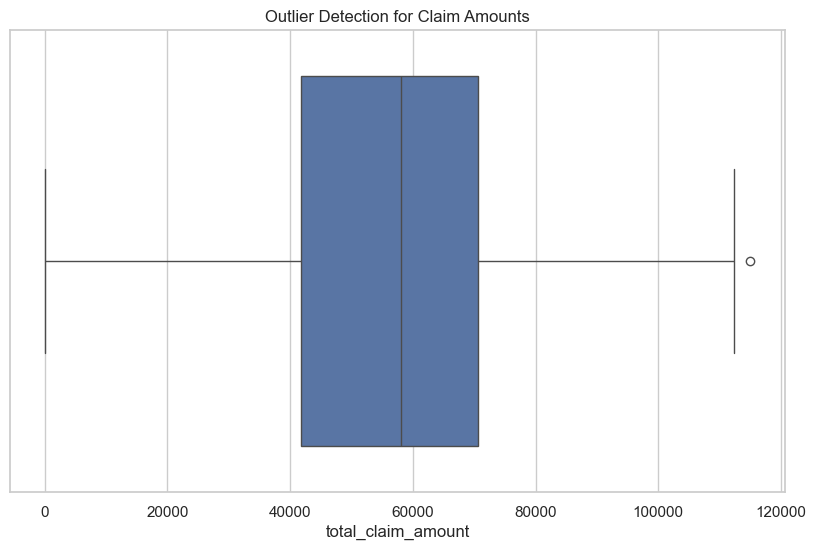

In [13]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df["total_claim_amount"]
)

plt.title("Outlier Detection for Claim Amounts")

plt.savefig("../reports/figures/outlier_claims.png")

plt.show()

# Multicollinearity Analysis

Multicollinearity occurs when predictor variables are highly correlated with one another.

This can destabilize regression coefficients and reduce model interpretability.

To assess multicollinearity, we compute the **Variance Inflation Factor (VIF)** for each predictor variable.

In [14]:
numeric_df = df.select_dtypes(include=[np.number]).copy()

X_vif = numeric_df.drop(columns=["total_claim_amount"])

X_vif = sm.add_constant(X_vif)

X_vif = X_vif.dropna()

vif = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) 
            for i in range(X_vif.shape[1])]
})

vif = vif.sort_values("VIF", ascending=False)

vif

,Feature,VIF
0,const,116146.309296
1,months_as_customer,7.731933
2,age,7.280020
19,incident_type,5.173644
27,number_of_vehicles_involved,5.125785
34,vehicle_claim,3.532937
33,property_claim,2.267303
32,injury_claim,2.194266
21,incident_severity,1.398462
22,authorities_contacted,1.250113


# Prepare Data for Modeling

In this section we prepare the dataset for machine learning models.

Steps include:

• Defining target variable  
• Preparing feature matrix  
• Encoding categorical variables  
• Splitting the dataset into training and testing sets

In [16]:
# Target variable
y = df["total_claim_amount"]

# Feature matrix
X = df.drop(columns=["total_claim_amount","fraud_reported"])

# One-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Train Test Split

The dataset is split into training and testing subsets to evaluate model performance on unseen data.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Feature Selection

Feature selection helps improve model performance and reduce overfitting by selecting the most informative predictors.

Here we use **SelectKBest with F-statistics**.

In [18]:
from sklearn.feature_selection import SelectKBest, f_regression

selector = SelectKBest(score_func=f_regression, k=15)

X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("Selected Features:")

print(selected_features)

Selected Features:
Index(['months_as_customer', 'age', 'insured_education_level', 'incident_type',
       'incident_severity', 'authorities_contacted',
       'incident_hour_of_the_day', 'number_of_vehicles_involved',
       'property_damage', 'injury_claim', 'property_claim', 'vehicle_claim',
       'claim_per_month', 'age_group_30-40', 'age_group_50-60'],
      dtype='str')


# Model Comparison

Before selecting the final model, we evaluate several machine learning algorithms.

Models evaluated:

• Linear Regression  
• Decision Tree  
• Random Forest  
• Gradient Boosting  
• Support Vector Regression  

Cross-validation is used to estimate generalization performance.

In [19]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR

models = {

"Linear Regression": LinearRegression(),

"Decision Tree": DecisionTreeRegressor(),

"Random Forest": RandomForestRegressor(),

"Gradient Boosting": GradientBoostingRegressor(),

"SVR": SVR()

}

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="r2"
    )

    print(name)

    print("Mean R2:", scores.mean())

    print("------------")

Linear Regression
Mean R2: 1.0
------------
Decision Tree
Mean R2: 0.9834928233951651
------------
Random Forest
Mean R2: 0.9941672721725017
------------
Gradient Boosting
Mean R2: 0.9982231290255557
------------
SVR
Mean R2: -0.04077873855193213
------------


# Pipeline with Scaling

Using a **Pipeline** ensures that preprocessing steps such as scaling are consistently applied during training and prediction.

This approach reflects best practices used in production machine learning systems.

In [20]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([

("scaler", StandardScaler()),

("model", RandomForestRegressor(
    n_estimators=300,
    random_state=42
))

])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_

# Model Evaluation

The trained model is evaluated using:

• R² Score  
• Root Mean Squared Error (RMSE)  
• Mean Absolute Error (MAE)

In [21]:
pred = pipeline.predict(X_test)

print("R2:", r2_score(y_test, pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

R2: 0.9938819639627436
RMSE: 2017.812383055251


In [22]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, pred)

print("MAE:", mae)

MAE: 1211.3976666666663


# Feature Importance

Understanding which features influence predictions is critical for interpretability.

Random Forest provides feature importance scores indicating the relative contribution of each predictor variable.

In [23]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

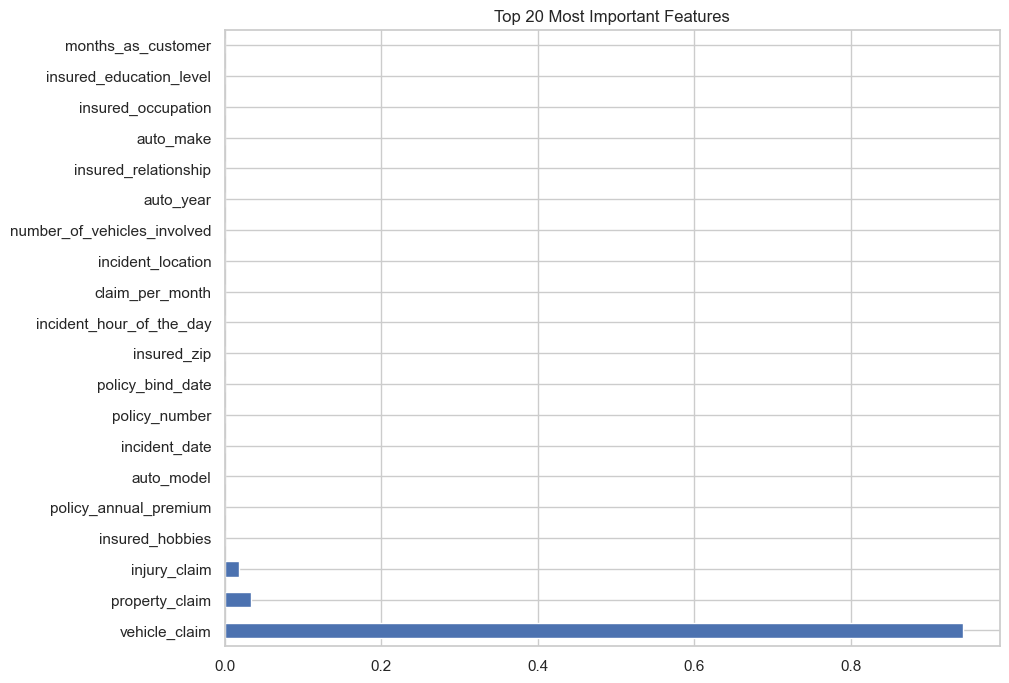

In [24]:
plt.figure(figsize=(10,8))

importance.head(20).plot(
    kind="barh"
)

plt.title("Top 20 Most Important Features")

plt.savefig("../reports/figures/feature_importance.png")

plt.show()

# Fraud Detection Model

Detecting fraudulent insurance claims is a high-priority task for insurance companies.

In this step we train a **Random Forest Classifier** to distinguish between legitimate and fraudulent claims.

In [25]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number]).copy()

# Features and target
X = numeric_df.drop(columns=["fraud_reported"], errors="ignore")

y = numeric_df["fraud_reported"]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

# Model Evaluation

In [28]:
pred = clf.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.78      0.90      0.83       145
           1       0.55      0.31      0.40        55

    accuracy                           0.74       200
   macro avg       0.66      0.61      0.61       200
weighted avg       0.71      0.74      0.71       200



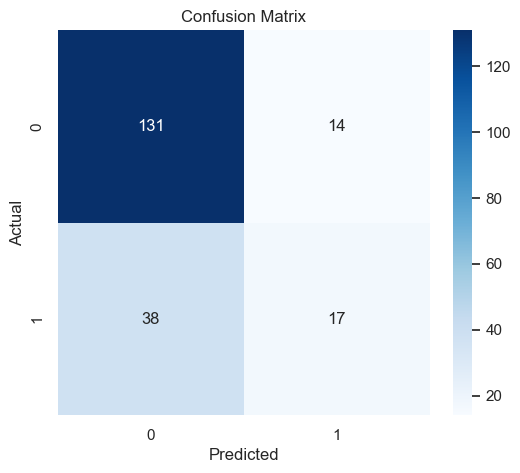

In [29]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.ylabel("Actual")

plt.xlabel("Predicted")

plt.savefig("../reports/figures/confusion_matrix.png")

plt.show()

# ROC Curve

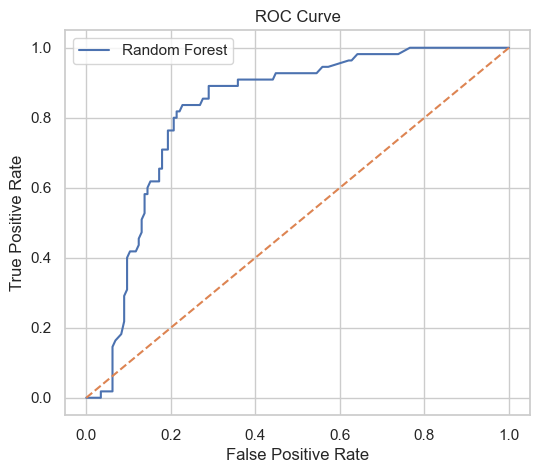

In [30]:
prob = clf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="Random Forest")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.savefig("../reports/figures/roc_curve.png")

plt.show()

# Customer Segmentation using Clustering

Clustering is used to identify natural groupings within the dataset.

This analysis applies **K-Means clustering** to discover segments of policyholders with similar claim characteristics.

In [31]:
numeric_df = df.select_dtypes(include=[np.number]).copy()

features = numeric_df.drop(columns=["fraud_reported"], errors="ignore")

scaler = StandardScaler()

scaled = scaler.fit_transform(features)

In [32]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(scaled)

# PCA Visualization

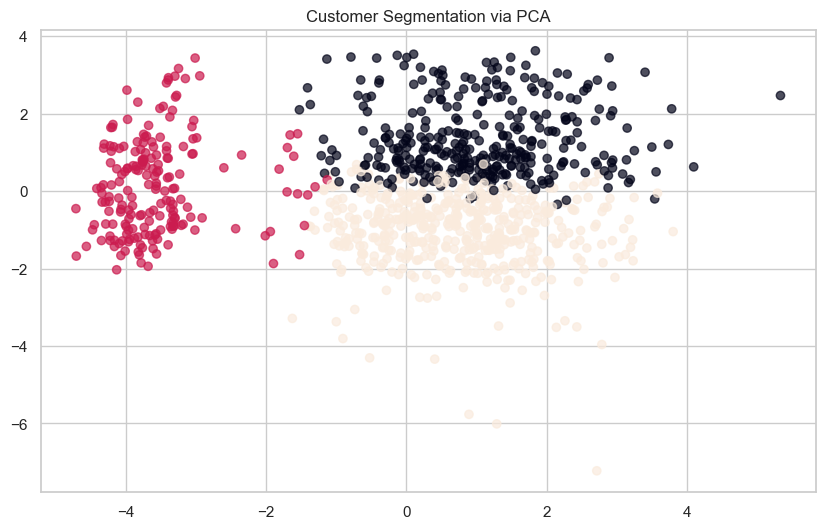

In [33]:
pca = PCA(n_components=2)

pca_res = pca.fit_transform(scaled)

plt.figure(figsize=(10,6))

plt.scatter(
    pca_res[:,0],
    pca_res[:,1],
    c=clusters,
    alpha=0.7
)

plt.title("Customer Segmentation via PCA")

plt.savefig("../reports/figures/customer_segments.png")

plt.show()

# Model Explainability using SHAP

Understanding model predictions is critical in real-world machine learning systems.

SHAP (SHapley Additive exPlanations) provides a method for explaining individual predictions and feature importance.

In [ ]:
import shap

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

In [ ]:
shap.summary_plot(
    shap_values,
    X_test
)

# Model Persistence

Saving trained models allows them to be reused later for predictions without retraining.

In [ ]:
import joblib

joblib.dump(
    rf,
    "../models/random_forest_model.joblib"
)

# Business Insights

The analysis reveals several key insights:

• Claim costs vary significantly across policyholders  
• Certain demographic and policy characteristics strongly influence claim size  
• Random Forest models provide strong predictive performance  
• Fraud classification models show promising detection capability  

These insights demonstrate how machine learning techniques can support insurance companies in improving risk assessment and fraud detection processes.

# Final Report

## Key Findings

• Claim amount distribution is highly skewed.

• Several demographic and policy variables influence claim cost.

• Random Forest achieved strong performance for claim prediction.

• Fraud detection model shows promising classification accuracy.

## Business Impact

These models can help insurance companies:

- improve risk assessment
- detect fraud earlier
- reduce financial losses
- optimize claim investigation processes

# Portfolio Summary

This project demonstrates a complete end-to-end machine learning workflow applied to an insurance claims dataset.

Key highlights include:

• Comprehensive data cleaning and preprocessing  
• Advanced exploratory data analysis with multiple visualizations  
• Feature engineering and feature selection  
• Comparison of multiple machine learning algorithms  
• Fraud detection using classification models  
• Customer segmentation using unsupervised learning  
• Model explainability using SHAP  
• Model persistence for deployment

This project reflects real-world data science workflows used in insurance analytics, risk modeling, and fraud detection systems.